In [18]:
import os
import sys

import time
import itertools
import numpy as np
import torch
from matplotlib.pylab import plt
import gc

lib_decompre = "/var/home/dotamthuc/Works/Compress3DGS/Differentiable3DPC-Decompression-and-Rendering/"
sys.path.insert(0, lib_decompre)

from libs.dataloader.View import View, ViewCreator
from libs.dataloader.Scene import Scene
import decompress_render


lib_svraster = "/var/home/dotamthuc/Works/Compress3DGS/Baselines/svraster"
sys.path.insert(0, lib_svraster)
from src.sparse_voxel_model import SparseVoxelModel

np.set_printoptions(precision=3, suppress=True)

torch.cuda.set_per_process_memory_fraction(0.9, 0)

In [3]:
def load_geometry_from_sparse_voxels_model(sourse_path, load_attribute_field=True):
    voxel_model_frame = SparseVoxelModel(
        n_samp_per_vox=1,
        sh_degree=3,
        ss=1.5,
        white_background=False,
        black_background=False,
    )
    voxel_model_frame.load(sourse_path)

    geometry_info = {}
    #morton_code
    geometry_info["morton_code_tensor"] = voxel_model_frame.octpath.clone().detach()

    #vox_roots
    vox_roots = (voxel_model_frame.vox_center - 0.5 * voxel_model_frame.vox_size)
    geometry_info["vox_roots_tensor"] = vox_roots.clone().detach()
    geometry_info["vox_length_tensor"] = voxel_model_frame.vox_size.clone().detach()

    # Geometry conners
    geometry_info["vox2corners_tensor"] = voxel_model_frame.vox_key.clone().detach()
    geometry_info["vox_params_geo_tensor"] = voxel_model_frame._geo_grid_pts.clone().detach()

    # Colors
    if load_attribute_field:
        # SH0 = 0.28209479177387814
        # static_color  = (voxel_model_frame._sh0 * SH0 + 0.5).clone().detach()
        # static_color[static_color<0.0] = 0.0
        # geometry_info["vox_params_color_tensor"] = static_color
        geometry_info["vox_params_color_tensor"] = torch.concat([
            voxel_model_frame.sh0[:, None, :], voxel_model_frame.shs[:, :, :]
        ], dim=1)


    del voxel_model_frame
    torch.cuda.empty_cache()

    return geometry_info


def resize_rendering(render, size, mode='bilinear', align_corners=False):
    return torch.nn.functional.interpolate(
        render[None], size=size, mode=mode, align_corners=align_corners, antialias=True)[0]


class DensityField:
    def __init__(
        self,
        source_path,
        num_sample_per_voxel=1,
        load_attribute_field=True
    ):
        # CONFIG INFO
        self.num_sample_per_voxel = num_sample_per_voxel

        geometry_info = load_geometry_from_sparse_voxels_model(source_path, load_attribute_field)
        #### Define the Density Field
        self.voxel_morton_code = geometry_info["morton_code_tensor"]
        self.voxel_position    = geometry_info["vox_roots_tensor"]
        self.voxel_size        = geometry_info["vox_length_tensor"]
        self.voxel2corner      = geometry_info["vox2corners_tensor"]
        self.corner_geo_params = geometry_info["vox_params_geo_tensor"]
        self.num_voxels        = self.voxel_morton_code.shape[0]

        #### Define current Attribute Field
        if load_attribute_field:
            self.voxel_attribute_field = geometry_info["vox_params_color_tensor"]
        else:
            self.voxel_attribute_field = torch.full(
                [self.num_voxels, 3], 0.0, 
                dtype=torch.float32
            )
    
    def apply_phi(self, view_info):
        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=self.voxel_attribute_field,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()

        return rendered_image
    
    
    def apply_phi_with_F(self, voxel_attribute, view_info):

        ss = 1.5
        w_src, h_src = view_info.render_width, view_info.render_height
        w, h = round(w_src * ss), round(h_src * ss)
        w_ss, h_ss = w / w_src, h / h_src

        # if voxel_attribute.shape != (self.num_voxels, 3):
        #     raise Exception(f"Expect voxel_attribute in is static voxels color ({self.num_voxels}, 3) but got", voxel_attribute.shape)

        camera_settings = decompress_render.renderer.CameraSettings(
            image_width=w,#view_info.render_width, 
            image_height=h,#view_info.render_height, 
            tanfovx=view_info.tanfovx, 
            tanfovy=view_info.tanfovy, 
            cx=view_info.cx * w_ss,
            cy=view_info.cy * h_ss,
            w2c_matrix=view_info.world2view.cuda(),
            c2w_matrix=view_info.view2world.cuda()
        )

        render_settings = decompress_render.renderer.RenderSettings(
            num_sample_per_vox=self.num_sample_per_voxel,
            bg_color=0.0,
            near=view_info.near,
            need_depth=False,
            track_max_w=False,
            debug=False,
        )

        out_color, out_depth, out_T, max_w = decompress_render.renderer.rasterize_voxels_main(
            camera_settings=camera_settings,
            render_settings=render_settings,
            morton_code=self.voxel_morton_code,
            vox_roots=self.voxel_position,
            vox_length=self.voxel_size,
            vox2corners=self.voxel2corner,
            vox_params_geo=self.corner_geo_params,
            vox_params_color=voxel_attribute,
        )
        out_color = out_color + out_T * out_color.mean((1,2), keepdim=True)
        # print(f"color.shape={out_color.shape}")
        out_color = resize_rendering(out_color, size=(h_src, w_src))

        rendered_image = torch.permute(out_color.clamp(0, 1), dims=(1, 2, 0)).detach()


        return rendered_image


In [4]:

SH_C0 = 0.28209479177387814
SH_C1 = 0.4886025119029199
SH_C2 = [
    1.0925484305920792,
    -1.0925484305920792,
    0.31539156525252005,
    -1.0925484305920792,
    0.5462742152960396
]
SH_C3 = [
    -0.5900435899266435,
    2.890611442640554,
    -0.4570457994644658,
    0.3731763325901154,
    -0.4570457994644658,
    1.445305721320277,
    -0.5900435899266435
]
def computeColorFromSH(
        dir, coefs_mask,
    ):

    dir_norm = np.sqrt(np.sum((dir**2)))
    # print(f"dir={dir} dir_norm={dir_norm}")
    dir = dir / dir_norm

    # // The implementation is loosely based on code for
    # // "Differentiable Point-Based Radiance Fields for
    # // Efficient View Synthesis" by Zhang et al. (2022)
    sh = coefs_mask[1:, :]
    sh0 = coefs_mask[0, :]

    # DEG 0
    result = SH_C0 * sh0

    #DEG 1
    x,y,z = dir[0], dir[1], dir[2]
    result = result - SH_C1 * y * sh[0] + SH_C1 * z * sh[1] - SH_C1 * x * sh[2]

    #DEG 2
    xx = x * x
    yy = y * y
    zz = z * z
    xy = x * y
    yz = y * z
    xz = x * z
    result = result + \
        SH_C2[0] * xy * sh[3] + \
        SH_C2[1] * yz * sh[4] + \
        SH_C2[2] * (2.0 * zz - xx - yy) * sh[5] + \
        SH_C2[3] * xz * sh[6] + \
        SH_C2[4] * (xx - yy) * sh[7]
    
    # DEG 3
    result = result + \
        SH_C3[0] * y * (3.0 * xx - yy) * sh[8] + \
        SH_C3[1] * xy * z * sh[9] + \
        SH_C3[2] * y * (4.0 * zz - xx - yy) * sh[10] + \
        SH_C3[3] * z * (2.0 * zz - 3.0 * xx - 3.0 * yy) * sh[11] + \
        SH_C3[4] * x * (4.0 * zz - xx - yy) * sh[12] + \
        SH_C3[5] * z * (xx - yy) * sh[13] + \
        SH_C3[6] * x * (xx - 3.0 * yy) * sh[14] 

    result = result
    # result[result<=0] = 0.0
    return result


In [5]:
scene_sourse = "/var/home/dotamthuc/Works/Compress3DGS/Data/mip-nerf-360/{}/".format("bicycle")
scene_dataset = Scene(
    scene_sourse, image_dir_name="images",
    res_downscale=0.0, res_width=1600,
    test_view_every=8
)
test_views = scene_dataset.get_test_views()

Read dataset in COLMAP format.
Done reading and creating views: 194 train views and 25 encoding views


In [6]:

checkpoint = "/var/home/dotamthuc/Works/Compress3DGS/Results/SVRaster-small/mip-nerf-360/bicycle/rate00/checkpoints/iter030000_model.pt"
ref_denfield= DensityField(checkpoint)

####
voxel_morton_code = ref_denfield.voxel_morton_code.detach().cpu().numpy()
voxel_position = ref_denfield.voxel_position.detach().cpu().numpy()
voxel_size = ref_denfield.voxel_size.detach().cpu().numpy()
voxel2corner = ref_denfield.voxel2corner.detach().cpu().numpy()
corner_geo_params = ref_denfield.corner_geo_params.detach().cpu().numpy()
num_voxels = ref_denfield.num_voxels
voxel_attribute_field = ref_denfield.voxel_attribute_field.detach().cpu().numpy()



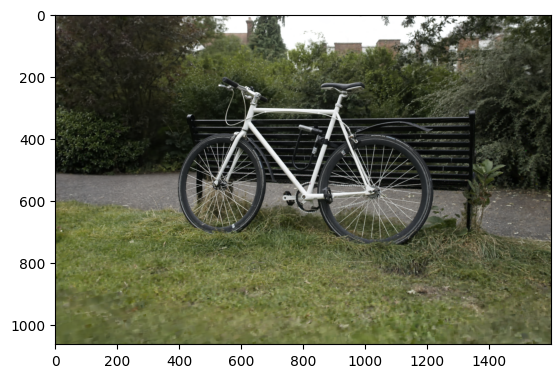

In [8]:
tensor_img_target = ref_denfield.apply_phi(test_views[0]).detach()
img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)
plt.imshow(img_target)
plt.show()

In [29]:
# A = []
# for k in range(3):
#     X = voxel_attribute_field[:, :, k]
#     # C = np.cov(X, rowvar=False)
#     # S, U = np.linalg.eig(C)
#     U, S, V = np.linalg.svd(X.T, full_matrices=False)
#     A.append(U)

In [ ]:
XtX = voxel_attribute_field.reshape(-1, 48).T @ voxel_attribute_field.reshape(-1, 48)
# # C = np.cov(X, rowvar=False)
# # S, U = np.linalg.eig(C)
U, S, V = np.linalg.svd(XtX)
X_transformed = (X @ U).reshape(-1, 16, 3)

dist = []
dist_sh = []
psnr = []
for ncoefs in range(1, 16):
    truncated_coefs = np.zeros_like(X_transformed)
    truncated_coefs[:, :ncoefs] = X_transformed[:, :ncoefs]

    recon_coefs = (truncated_coefs.reshape(-1, 48) @ U.T).reshape(-1, 16, 3)
    mse_sh = np.square(recon_coefs - voxel_attribute_field).mean()
    dist_sh.append(mse_sh)

    list_mse = []
    pick_view_i = 0
    with torch.no_grad():

        recon_coefs_tensor = torch.tensor(recon_coefs, device="cuda", dtype=torch.float)
        for view_i, view in enumerate(test_views):
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img

    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(10 * np.log10(np.mean(list_mse)))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')

print(f"psnr={psnr}")



ncoefs=1, psnr=23.8291
ncoefs=2, psnr=25.1705
ncoefs=3, psnr=26.7152
ncoefs=4, psnr=29.8442
ncoefs=5, psnr=35.8578
ncoefs=6, psnr=37.1777
ncoefs=7, psnr=38.4078
ncoefs=8, psnr=40.1011
ncoefs=9, psnr=41.9554
ncoefs=10, psnr=45.8117
ncoefs=11, psnr=46.4091
ncoefs=12, psnr=46.92
ncoefs=13, psnr=48.3436
ncoefs=14, psnr=50.6533
ncoefs=15, psnr=58.6772
psnr=[23.8291, 25.1705, 26.7152, 29.8442, 35.8578, 37.1777, 38.4078, 40.1011, 41.9554, 45.8117, 46.4091, 46.92, 48.3436, 50.6533, 58.6772]


Text(0.5, 1.0, 'Bicycle Scene')

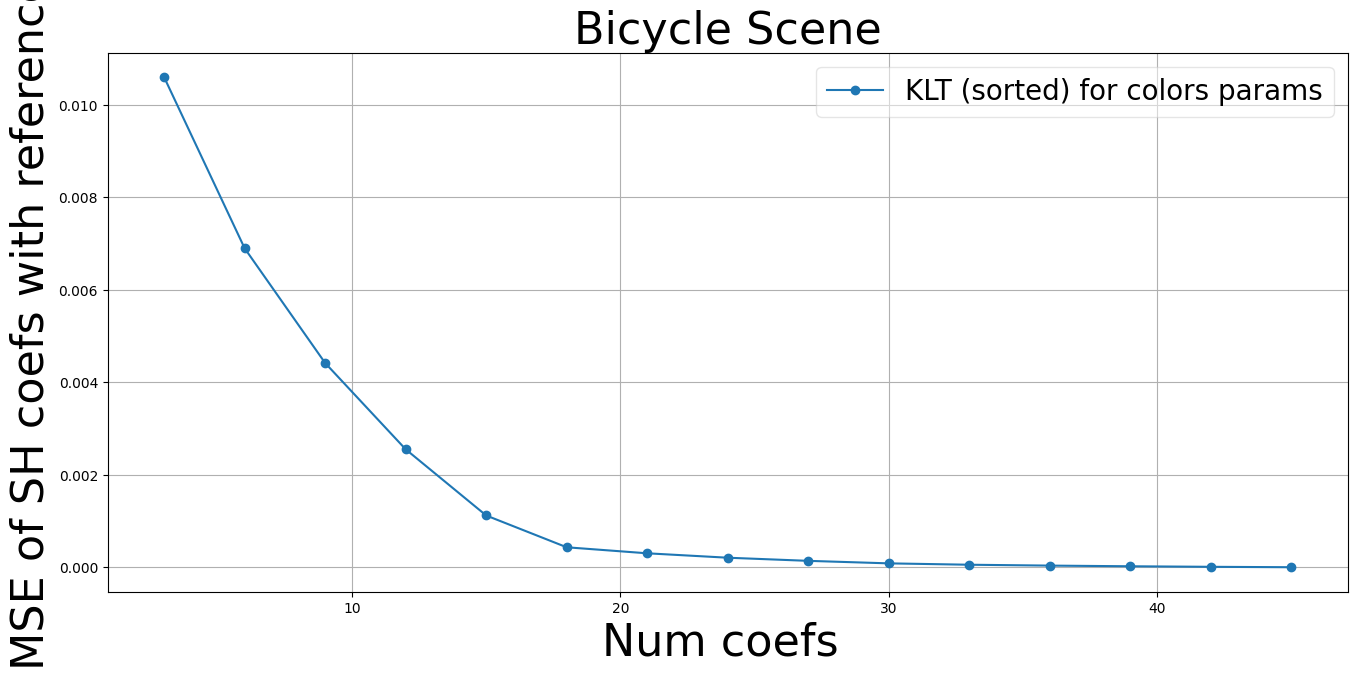

In [22]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


## BASELINE 
mse = np.array(dist_sh)
ax.plot(np.arange(1, 16)*3, mse, '-o', label="KLT (sorted) for colors params")


############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
plt.ylabel('MSE of SH coefs with reference', fontsize=32)
plt.title('Bicycle Scene', fontsize=32)

In [14]:
# fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


# ## BASELINE 
# psnr_sh = -10 * np.log10(np.array(dist_sh))
# ax.plot(np.arange(1, 16)*3, dist_sh, '-o', label="KLT (sorted) for colors params")


# ############ 
# # plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# # plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
# plt.grid()
# plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
# plt.xlabel('Num coefs ', fontsize=32)
# plt.ylabel('MSE of SH coefs with reference', fontsize=22)
# plt.title('Bicycle Scene', fontsize=32)

In [ ]:
list_dir = [
    (-1, -1, -1), (-1, -1, 0), (-1, -1, 1), 
    (-1, 0, -1), (-1, 0, 0), (-1, 0, 1), 
    (-1, 1, -1), (-1, 1, 0), (-1, 1, 1),
    (0, -1, -1), (0, -1, 0), (0, -1, 1), 
    (0, 0, -1), (0, 0, 1), 
    (0, 1, -1), (0, 1, 0), (0, 1, 1), 
    (1, -1, -1), (1, -1, 0), (1, -1, 1), 
    (1, 0, -1), (1, 0, 0), (1, 0, 1), 
    (1, 1, -1), (1, 1, 0), (1, 1, 1)
]
transformM = []
for dir in list_dir:
    out_dir = []
    for c_i in range(16):
        out_c_i = []
        for k in range(3):
            coefs = np.zeros((16, 3))
            coefs[c_i, k] = 1.0
            out_c_i.append(computeColorFromSH(np.array(dir), coefs))
        out_dir.append(out_c_i)
    transformM.append(out_dir)
    
transformM = np.array(transformM)
print(f"transformM.shape={transformM.shape}")
transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(26*3, 16*3)
print(f"transformM.shape={transformM.shape}")

# transformM = []
# for dir_i in range(10):
#     out_dir = []
#     for c_i in range(16):
#         out_c_i = []
#         for k in range(3):
#             coefs = np.zeros((16, 3))
#             coefs[c_i, k] = 1.0
#             out_c_i.append(computeColorFromSH(np.random.uniform(-1, 1, size=(3)), coefs))
#         out_dir.append(out_c_i)
#     transformM.append(out_dir)
    
# transformM = np.array(transformM)
# print(f"transformM.shape={transformM.shape}")
# transformM = np.transpose(transformM, (0, 3, 1, 2)).reshape(10*3, 48)
# print(f"transformM.shape={transformM.shape}")

transformM.shape=(26, 16, 3, 3)
transformM.shape=(78, 48)


In [28]:
M = transformM[:, :]
MtM = (M.T @ M)
U, S, Vt = np.linalg.svd(MtM)
MtT_sqrt_inv = U.T @ np.diag(1/np.sqrt(S)) @ U
# U =  U[:, np.argsort(S)]
transform = MtM @ MtT_sqrt_inv
inv_transform = MtT_sqrt_inv

In [34]:
X_transformed = (voxel_attribute_field.reshape(-1, 48) @ transform).reshape(-1, 16, 3)
np.std(X_transformed, axis=0).reshape(16, 3)

array([[2.205, 1.83 , 3.219],
       [0.146, 0.144, 0.166],
       [0.128, 0.119, 0.149],
       [0.123, 0.117, 0.144],
       [0.159, 0.156, 0.181],
       [0.162, 0.165, 0.186],
       [0.114, 0.111, 0.128],
       [0.146, 0.139, 0.173],
       [0.129, 0.124, 0.142],
       [0.175, 0.172, 0.191],
       [0.174, 0.173, 0.193],
       [0.169, 0.165, 0.182],
       [0.144, 0.137, 0.159],
       [0.153, 0.149, 0.172],
       [0.16 , 0.157, 0.175],
       [0.158, 0.159, 0.176]])

In [35]:
dist = []
psnr = []
for ncoefs in range(1, 16):
    # truncated_coefs = np.zeros_like(X_transformed)
    # truncated_coefs[:, :ncoefs] = X_transformed[:, :ncoefs]
    recon_coefs = (X_transformed[:, :ncoefs].reshape(-1, ncoefs*3) @ inv_transform[:ncoefs*3, :]).reshape(-1, 16, 3)
    recon_coefs = recon_coefs.astype(np.float32)
    
    list_mse = []
    pick_view_i = 0
    with torch.no_grad():
        recon_coefs_tensor = torch.from_numpy(recon_coefs).cuda()
        for view_i, view in enumerate(test_views):
            # print(f"view_i={view_i}")
            tensor_img = ref_denfield.apply_phi_with_F(recon_coefs_tensor, view).detach()
            rendered_img = tensor_img.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            tensor_img_target = ref_denfield.apply_phi(view).detach()
            img_target = tensor_img_target.clamp(0, 1).mul(255).cpu().numpy().astype(np.uint8)

            mse = np.square(img_target/255 - rendered_img/255).mean()
            list_mse.append(mse)

            if view_i == pick_view_i:
                rendered_img_picked = rendered_img
        
        torch.cuda.empty_cache()


    # Print details.
    dist.append(np.mean(list_mse))
    psnr.append(np.round(-10 * np.log10(np.mean(list_mse)), 4))

    print(f'ncoefs={ncoefs}, psnr={psnr[-1]}')
print(f"psnr={psnr}")

ncoefs=1, psnr=23.6509
ncoefs=2, psnr=24.4127
ncoefs=3, psnr=24.9678
ncoefs=4, psnr=25.676
ncoefs=5, psnr=25.943
ncoefs=6, psnr=26.1317
ncoefs=7, psnr=26.6628
ncoefs=8, psnr=27.5143
ncoefs=9, psnr=28.1836
ncoefs=10, psnr=28.6964
ncoefs=11, psnr=29.0523
ncoefs=12, psnr=29.5595
ncoefs=13, psnr=30.8539
ncoefs=14, psnr=32.8194
ncoefs=15, psnr=35.0156
psnr=[23.6509, 24.4127, 24.9678, 25.676, 25.943, 26.1317, 26.6628, 27.5143, 28.1836, 28.6964, 29.0523, 29.5595, 30.8539, 32.8194, 35.0156]


Text(0.5, 1.0, 'Bicycle Scene')

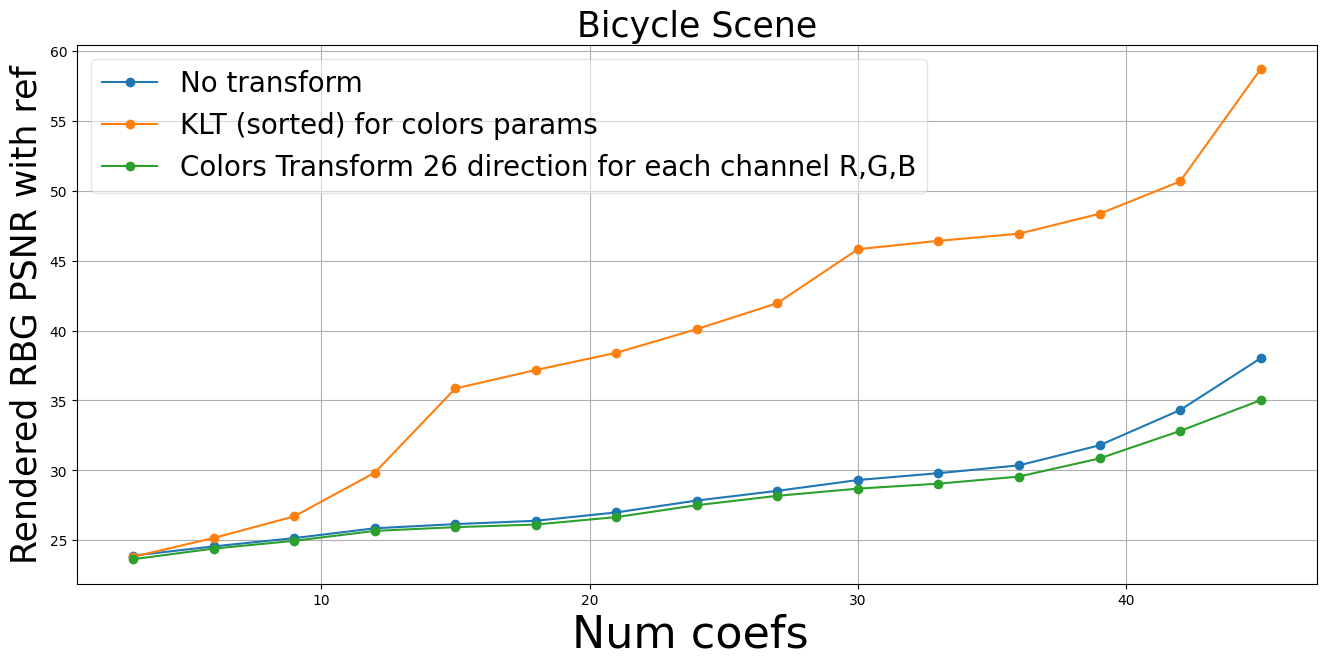

In [42]:
fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


## BASELINE 

psnr=[23.9083, 24.5693, 25.1598, 25.8635, 26.1601, 26.4003, 26.9967, 27.8473, 28.5388, 29.3123, 29.8021, 30.3615, 31.7934, 34.3099, 38.0124]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="No transform")

psnr=[23.8291, 25.1705, 26.7152, 29.8442, 35.8578, 37.1777, 38.4078, 40.1011, 41.9554, 45.8117, 46.4091, 46.92, 48.3436, 50.6533, 58.6772]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="KLT (sorted) for colors params")

psnr=[23.6509, 24.4127, 24.9678, 25.676, 25.943, 26.1317, 26.6628, 27.5143, 28.1836, 28.6964, 29.0523, 29.5595, 30.8539, 32.8194, 35.0156]
ax.plot(np.arange(1, 16)*3, psnr, '-o', label="Colors Transform 26 direction for each channel R,G,B")


# psnr=[23.9083, 24.6333, 25.2209, 25.9682, 26.2385, 26.4643, 27.02, 27.9293, 28.6322, 29.1693, 29.5388, 30.0412, 31.3221, 33.295, 35.4872]
# ax.plot(np.arange(1, 16), psnr, '-o', label="Colors Transform - KLT of 26 direction ")


############ 
# plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
plt.grid()
plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
plt.xlabel('Num coefs ', fontsize=32)
# plt.xlim((0.3, 2.8))
# plt.ylim((36, 46.0))
plt.ylabel('Rendered RBG PSNR with ref', fontsize=25)
plt.title('Bicycle Scene', fontsize=25)

In [37]:
# fig, ax = plt.subplots(ncols=1, nrows=1, figsize=(16, 7))


# ## BASELINE 
# psnr=[23.9083, 24.5693, 25.1598, 25.8635, 26.1601, 26.4003, 26.9967, 27.8473, 28.5388, 29.3123, 29.8021, 30.3615, 31.7934, 34.3099, 38.0124]
# ax.plot(np.arange(1, 16), psnr, '-o', label="No transform")

# psnr=[24.0873, 25.4551, 27.1102, 29.721, 36.0953, 37.4836, 38.7328, 40.5503, 41.9651, 46.0744, 46.8254, 47.2967, 48.6818, 50.8124, 58.0856]
# ax.plot(np.arange(1, 16), psnr, '-o', label="KLT (sorted) for colors params")

# # psnr=[23.8876, 25.2914, 26.8098, 29.1258, 36.0901, 37.4846, 38.7185, 40.4601, 41.7265, 45.8464, 46.4718, 46.8156, 47.2296, 49.0935, 50.9584]
# # ax.plot(np.arange(1, 16), psnr, '-o', label="KLT (old-unsorted) for colors params")


# psnr=[23.9083, 24.6333, 25.2209, 25.9682, 26.2385, 26.4643, 27.02, 27.9293, 28.6322, 29.1693, 29.5388, 30.0412, 31.3221, 33.295, 35.4872]
# ax.plot(np.arange(1, 16), psnr, '-o', label="Colors Transform 26 direction for each channel R,G,B")


# # psnr=[23.9083, 24.6333, 25.2209, 25.9682, 26.2385, 26.4643, 27.02, 27.9293, 28.6322, 29.1693, 29.5388, 30.0412, 31.3221, 33.295, 35.4872]
# # ax.plot(np.arange(1, 16), psnr, '-o', label="Colors Transform - KLT of 26 direction ")


# ############ 
# # plt.yticks(ticks=np.arange(20, 48, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(20, 48, step=0.5))], fontsize=32)
# # plt.xticks(ticks=np.arange(0, 7, step=0.5), labels=["{:.1f}".format(x) if i%2==0 else "" for i, x in enumerate(np.arange(0, 7, step=0.5))], rotation=45, fontsize=32)
# plt.grid()
# plt.legend(fancybox=True, framealpha=0.5, prop={'size': 20})
# plt.xlabel('Num triplets coefs ', fontsize=32)
# # plt.xlim((0.3, 2.8))
# # plt.ylim((36, 46.0))
# plt.ylabel('Rendered RBG PSNR (dB) with reference', fontsize=32)
# plt.title('Bicycle Scene', fontsize=32)